In [2]:
from sklearn.datasets import fetch_openml
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame
X = df.drop("MEDV", axis=1)
y = df["MEDV"]
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [2]:
df.info() # kiểm tra kiểu dữ liệu
df.describe() #thống kê mô tả các biến dạng numerical trong data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


In [3]:
print(df.isnull().sum()) # kiểm tra dữ liệu null

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


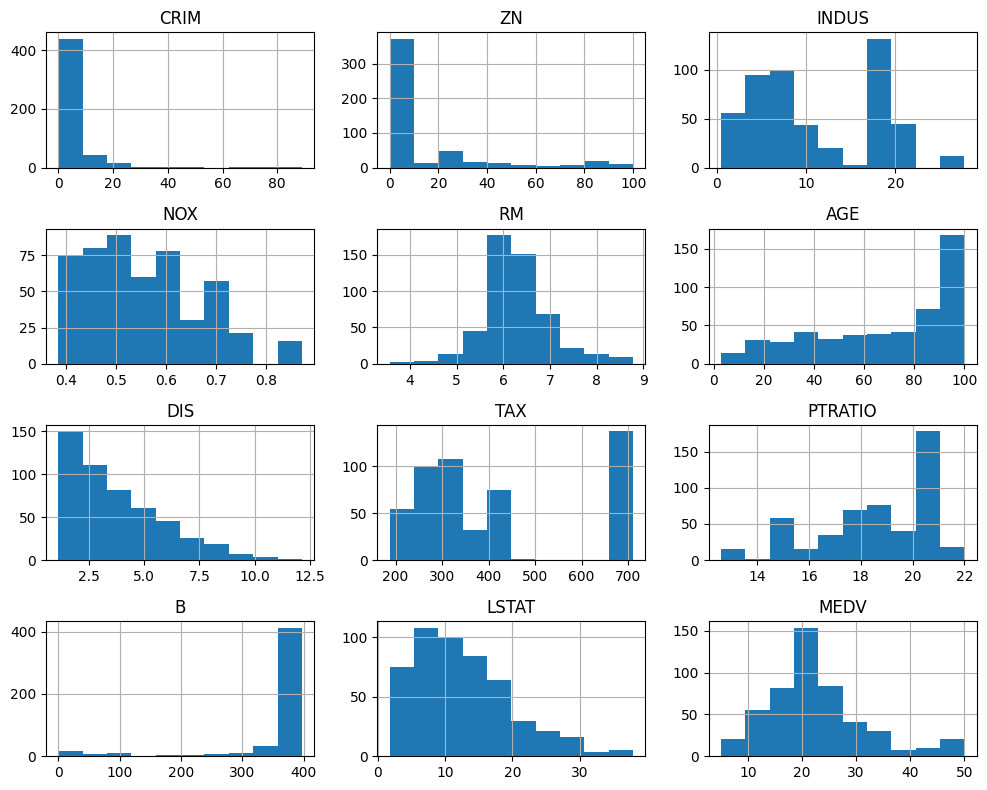

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df.hist( bins=10,figsize=(10,8))
plt.tight_layout()
plt.show()

In [4]:
df.corr(method="pearson") #pearson is the default method 

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


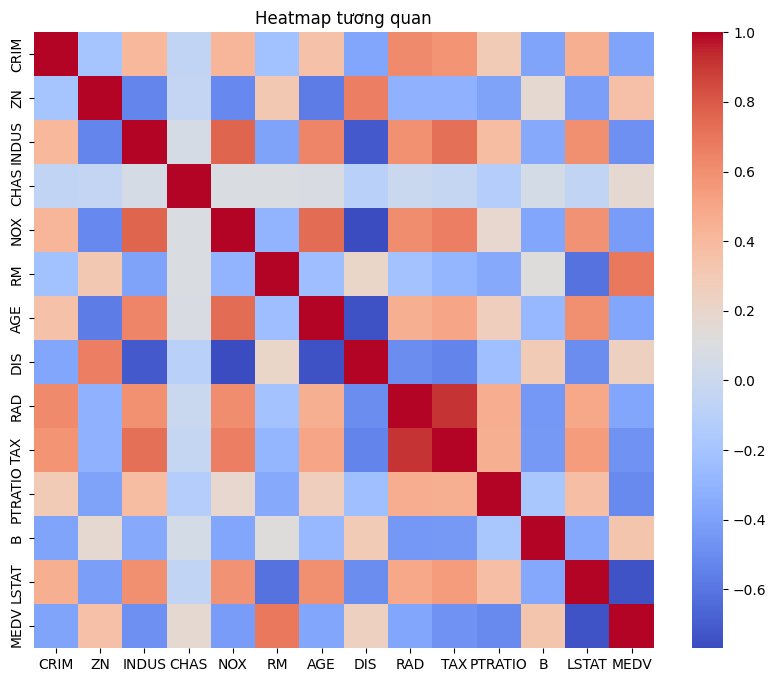

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Heatmap tương quan")
plt.show()
#Để ý 2 feature có độ tương quan mạnh với nhau => xử lí multicollineary 

In [7]:
df.shape

(506, 14)

In [6]:
from sklearn.preprocessing import StandardScaler
X = df.drop("MEDV", axis=1)  # input features
y = df["MEDV"]               # target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(354, 13)
(354,)
(152, 13)
(152,)


In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Linear': LinearRegression(),
    'Ridge(α=20)': Ridge(alpha=20),
    'Lasso(α=0.1)': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

for name , model in models.items(): 
    model.fit(X_train, y_train)
    mae = mean_absolute_error(y_test, model.predict(X_test))
    print(f"Model {name} have a mae of : {mae:.4f}")

#Kết luận : 
## Model ElasticNet có độ chính xác thấp nhất , do model làm tăng độ phức tạp so với tệp dữ liệu nhỏ dù xử lí feature selection lẫn multicollineary 
## Model linear , ko xử lí được multicollineary nên có độ chính xác cao nhì 
## Model Lasso có alpha 0.1 (chưa rõ đã tối ưu chưa) làm giảm độ phức tạp mô hình phù hợp hơn với dataset nhỏ 
## Model ridge đã xử lí được multicollineary trong mô hình 
## ridge thì giảm coef của hệ số hồi quy , lasso thì có thể giảm về 0 để loại bỏ những hệ số hồi quy ko quan trọng
## tăng alpha thì cả 2 đều khiến mô hình đơn giản hơn (coef giảm về 0 hoặc bằng 0 sẽ ít học những noise)
## khiến overfitting giảm nhưng có thể tăng underfitting (bias - variance tradeoff )

Model Linear have a mae of : 3.1627
Model Ridge(α=20) have a mae of : 3.1463
Model Lasso(α=0.1) have a mae of : 3.1574
Model ElasticNet have a mae of : 3.1744


In [20]:
for name, model in models.items():
    coef = model.coef_
    print(f"Model {name} has a coefficient of {coef}")

    

Model Linear has a coefficient of [-1.14691411  0.83432605  0.33940694  0.79163612 -1.784727    2.84783949
 -0.30429306 -2.91562521  2.11140045 -1.46519951 -1.9696347   1.07567771
 -3.90310727]
Model Ridge(α=20) has a coefficient of [-0.9696301   0.57051111  0.01249903  0.85816608 -1.28618404  2.90792449
 -0.32711947 -2.30931066  1.15564573 -0.7159518  -1.81731511  1.01921448
 -3.63437452]
Model Lasso(α=0.1) has a coefficient of [-1.11450695  0.78137768  0.24493562  0.7965148  -1.71612101  2.85109962
 -0.28491702 -2.84527183  1.92562146 -1.28230924 -1.95094486  1.06160594
 -3.90424751]
Model ElasticNet has a coefficient of [-0.86688991  0.44750769 -0.          0.8412555  -1.16406534  2.93119876
 -0.24527415 -2.05586201  0.75607292 -0.40199122 -1.77802142  0.97282089
 -3.67239531]


Ridge Regression (α=20) đem lại MAE = 3.165 nhỏ nhất trên dữ liệu test, chứng tỏ regularization L2 giúp cải thiện generalization tốt hơn trong trường hợp multicollinearity của Boston Housing.

# Linear regression

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [11]:
import numpy as np
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.7112
MAE: 3.1627
MSE: 21.5174
RMSE: 4.6387


#Ridge Regression

In [13]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
parameters = {'alpha': [1e-3 , 1e-2 , 1 , 5, 10 , 20 ]}
ridge_regression = GridSearchCV(ridge , parameters , scoring='neg_mean_absolute_error', cv = 5)
ridge_regression.fit(X_train, y_train)
print(f"alpha : {ridge_regression.best_params_}")
print(f"best alpha's  average validation errors : {ridge_regression.best_score_}")



alpha : {'alpha': 20}
best alpha's  average validation errors : -3.505228754908559


In [14]:
prediction_ridge = ridge_regression.predict(X_test)
mae_ridge = mean_absolute_error(y_test , prediction_ridge)
print(f"Mae score for ridge regression : {mae_ridge}")

Mae score for ridge regression : 3.1462569735833066


# Lasso Regression

In [15]:
from sklearn.linear_model import Lasso 
from sklearn.model_selection import GridSearchCV 

lasso = Lasso()
parameters = {'alpha': [1e-3 , 1e-2 , 1, 5 , 10 , 20]}
lasso_regression = GridSearchCV(lasso , parameters , scoring="neg_mean_absolute_error", cv =5 )
lasso_regression.fit(X_train , y_train)
print(f" Lasso regression best alpha parameter : {lasso_regression.best_params_}")
print(f"Lasso regression average validation errors : {lasso_regression.best_score_}")

 Lasso regression best alpha parameter : {'alpha': 0.01}
Lasso regression average validation errors : -3.5653058128694406


In [16]:
prediction_lasso = lasso_regression.predict(X_test)
mae_lasso = mean_absolute_error(y_test, prediction_lasso)
print(f"Lasso regression mae : {mae_lasso:.4f}")

Lasso regression mae : 3.1574


# Visualize

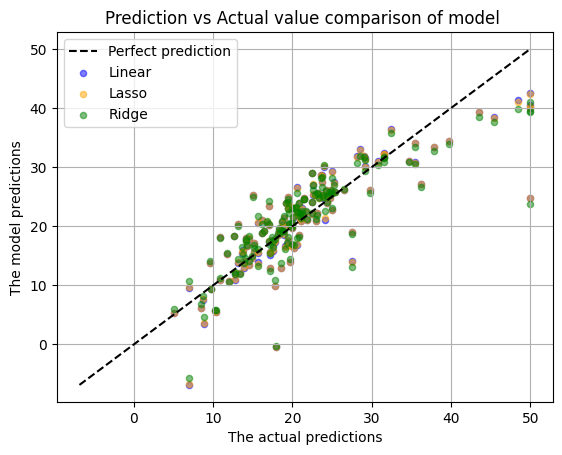

In [31]:
import matplotlib.pyplot as plt 
import numpy as np 

model_names = ['Linear', 'Lasso', 'Ridge']
predict = [y_pred, prediction_lasso, prediction_ridge]
color = ['blue', 'orange', 'green']

val_max = max(np.max(y_test), max( [np.max(p) for p in predict] ))
val_min = min(np.min(y_test), min(np.min(p) for p in predict))
plt.plot([val_min , val_max], [val_min, val_max], 'k--', label = "Perfect prediction")

for i , (model_names, predict , color) in enumerate(zip(model_names, predict , color)):
    plt.scatter(y_test , predict , label = model_names, color = color , alpha  = 0.5 , s = 20)

plt.title("Prediction vs Actual value comparison of model ")
plt.grid(True)
plt.xlabel("The actual predictions")
plt.ylabel("The model predictions")
plt.legend()
plt.show()



    






# Elastic Net

- Làm chi tiết bước chọn tham số -> best param -> áp dụng best param này cho mô hình ElasticNet
- Huấn luyện mô hình ElasticNet
- Evaluated mô hình dựa vào các metric (MAE)
- Add thêm vào chart visualize kết quả của ElasticNet

In [17]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV 
ElasticNet_model = ElasticNet()
parameters = {
    'alpha': [0.001 , 0.01 , 0.1 , 0.3 , 0.5 , 1],
    'l1_ratio': [0.1, 0.3 , 0.5 , 0.7 , 0.9],
}
ElasticNet_regressor = GridSearchCV(ElasticNet_model, parameters , scoring= 'neg_mean_absolute_error',cv =5)

ElasticNet_regressor.fit(X_train , y_train)
print(f"Elastic Net regressor best parameters (alpha and l1 ratio): {ElasticNet_regressor.best_params_}")
print(f"Elastic Net regressor mae scoring {ElasticNet_regressor.best_score_}")



Elastic Net regressor best parameters (alpha and l1 ratio): {'alpha': 0.1, 'l1_ratio': 0.1}
Elastic Net regressor mae scoring -3.50008813130734


In [18]:
# Dự đoán trên tập test
prediction_elasticnet = ElasticNet_regressor.predict(X_test)

# Tính MAE
mae_elasticnet = mean_absolute_error(y_test, prediction_elasticnet)
print(f"MAE ElasticNet: {mae_elasticnet:.4f}")

MAE ElasticNet: 3.1609


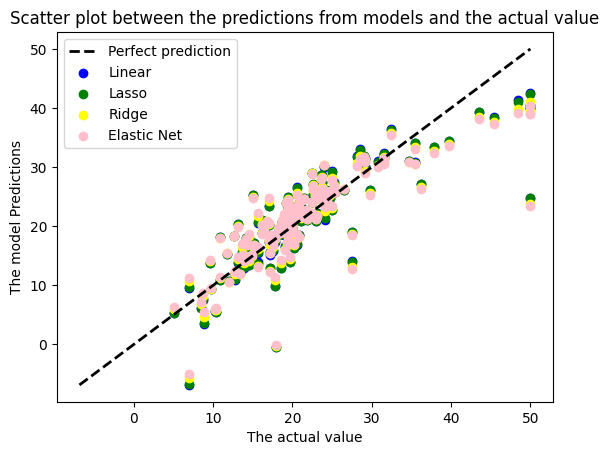

In [19]:
import matplotlib.pyplot as plt 
import numpy as np 

model_names  = ['Linear', 'Lasso', 'Ridge', 'Elastic Net']
model_predictions = [y_pred, prediction_lasso, prediction_ridge, prediction_elasticnet]
color = ['blue', 'green', 'yellow', 'pink']

max_val = max(np.max(y_test), max(np.max(p) for p in model_predictions))
min_val = min(np.min(y_test), min(np.min(p) for p in model_predictions))
plt.plot([min_val , max_val], [min_val , max_val],  'k--', label = "Perfect prediction", linewidth = 2 )

for i , (model_names, model_predictions, color ) in enumerate(zip(model_names, model_predictions, color)): 
    plt.scatter(y_test ,model_predictions, label = model_names , color = color )

plt.title("Scatter plot between the predictions from models and the actual value")
plt.xlabel("The actual value")
plt.ylabel("The model Predictions")
plt.legend()
plt.show()





In [20]:
# So sánh MAE của tất cả các model
print("=" * 50)
print("SO SÁNH MAE CỦA CÁC MÔ HÌNH")
print("=" * 50)
print(f"Linear Regression:  MAE = {mae:.4f}")
print(f"Ridge Regression:   MAE = {mae_ridge:.4f}")
print(f"Lasso Regression:   MAE = {mae_lasso:.4f}")
print(f"ElasticNet:         MAE = {mae_elasticnet:.4f}")
print("=" * 50)

SO SÁNH MAE CỦA CÁC MÔ HÌNH
Linear Regression:  MAE = 3.1627
Ridge Regression:   MAE = 3.1463
Lasso Regression:   MAE = 3.1574
ElasticNet:         MAE = 3.1609
